# Bosques Aleatorios (Random Forest)

Vimos que un árbol de decisión, entrenado sin límites, es capaz de ajustarse *perfectamente* a los datos de entrenamiento. Pero esa misma virtud es también su problema: un árbol muy profundo tiende a **sobreajustarse** (aprende el ruido de los datos, no solo el patrón general) y además es bastante **inestable**, ya que un pequeño cambio en los datos de entrenamiento puede generar un árbol completamente distinto.

Los **Bosques Aleatorios** resuelven ambos problemas con una idea simple: en lugar de confiar en un único árbol, entrenamos **muchos árboles distintos** y dejamos que **voten** entre todos cuál es la predicción final. Esta idea se conoce como *"la sabiduría de las masas"*: aunque cada árbol individual pueda equivocarse, el promedio de muchos árboles imperfectos suele ser más preciso y más estable que cualquiera de ellos por separado.

## ¿Cómo se logra que los árboles sean distintos entre sí?

Si entrenáramos 100 árboles con exactamente los mismos datos y los mismos parámetros, los 100 saldrían idénticos, y "votar" entre copias iguales no aportaría nada. Para lograr diversidad, un Bosque Aleatorio introduce **dos fuentes de aleatoriedad** a la hora de entrenar cada árbol:

1. **Bootstrap (bagging):** cada árbol se entrena con una muestra aleatoria *con reposición* de las filas del dataset original (del mismo tamaño que el original, pero con filas repetidas y otras ausentes). A esto se le llama *Bagging* (**B**ootstrap **Agg**regat**ing**).
2. **Selección aleatoria de variables:** en cada división (cada "pregunta") de cada árbol, el algoritmo no evalúa todas las columnas disponibles, sino solo un **subconjunto aleatorio** de ellas. Esto evita que todos los árboles giren siempre alrededor de la variable más fuerte (en nuestro caso, `petal_length`) y fuerza a que exploren otras combinaciones.

La combinación de estas dos técnicas es lo que hace que cada árbol del bosque "vea" un problema ligeramente distinto, y por lo tanto llegue a conclusiones ligeramente distintas. Empecemos importando lo que vamos a necesitar.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Vamos a trabajar con el **mismo dataset** que usamos la clase pasada, `iris` de Seaborn, para poder comparar los resultados del bosque contra los del árbol individual.

In [ ]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Repetimos la misma preparación de datos que hicimos con el árbol: separamos las variables independientes (`X`) de la variable dependiente (`species`), codificamos esta última con `LabelEncoder`, y dividimos en entrenamiento y prueba usando el  `random_state=42` , para que ambos modelos compitan con exactamente la misma división de datos.

In [ ]:
X= df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df["species"]

y = LabelEncoder().fit_transform(df["species"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Un árbol, como punto de referencia

Antes de entrenar el bosque, entrenamos un único árbol de decisión (sin límite de profundidad, igual que al comienzo de la clase pasada) para tener una **línea base** contra la cual comparar.

In [ ]:
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)

y_pred_arbol = arbol.predict(X_test)
acc_arbol = accuracy_score(y_test, y_pred_arbol)
print(f"Accuracy del árbol único: {acc_arbol:.2f}")

Accuracy del árbol único: 0.93


## Entrenando un Bosque Aleatorio

Para crear un bosque usamos `RandomForestClassifier`, que en el fondo es una colección de `DecisionTreeClassifier` entrenados como explicamos arriba. Sus hiperparámetros más importantes son:

* **`n_estimators`**: cuántos árboles va a tener el bosque. Más árboles suelen dar predicciones más estables, a costa de mayor tiempo de cómputo.
* **`max_features`**: cuántas variables se consideran, como máximo, en cada división de cada árbol (por defecto, la raíz cuadrada del total de variables para clasificación).
* **`bootstrap`**: si es `True` (el valor por defecto), cada árbol se entrena con una muestra bootstrap de los datos, tal como describimos antes.
* **`random_state`**: igual que con el árbol, fija la semilla aleatoria para que el resultado sea reproducible.

Empecemos con un bosque de 100 árboles.

In [ ]:
bosque = RandomForestClassifier(n_estimators=100, random_state=42)
bosque.fit(X_train, y_train)

y_pred_bosque = bosque.predict(X_test)
acc_bosque = accuracy_score(y_test, y_pred_bosque)
print(f"Accuracy del bosque: {acc_bosque:.2f}")

Accuracy del bosque: 0.90


Nuestro bosque ya está entrenado, y por dentro contiene 100 árboles de decisión distintos, accesibles desde `bosque.estimators_`. Veamos tres de ellos, uno al lado del otro, para comprobar que —tal como esperábamos— **no son iguales**.

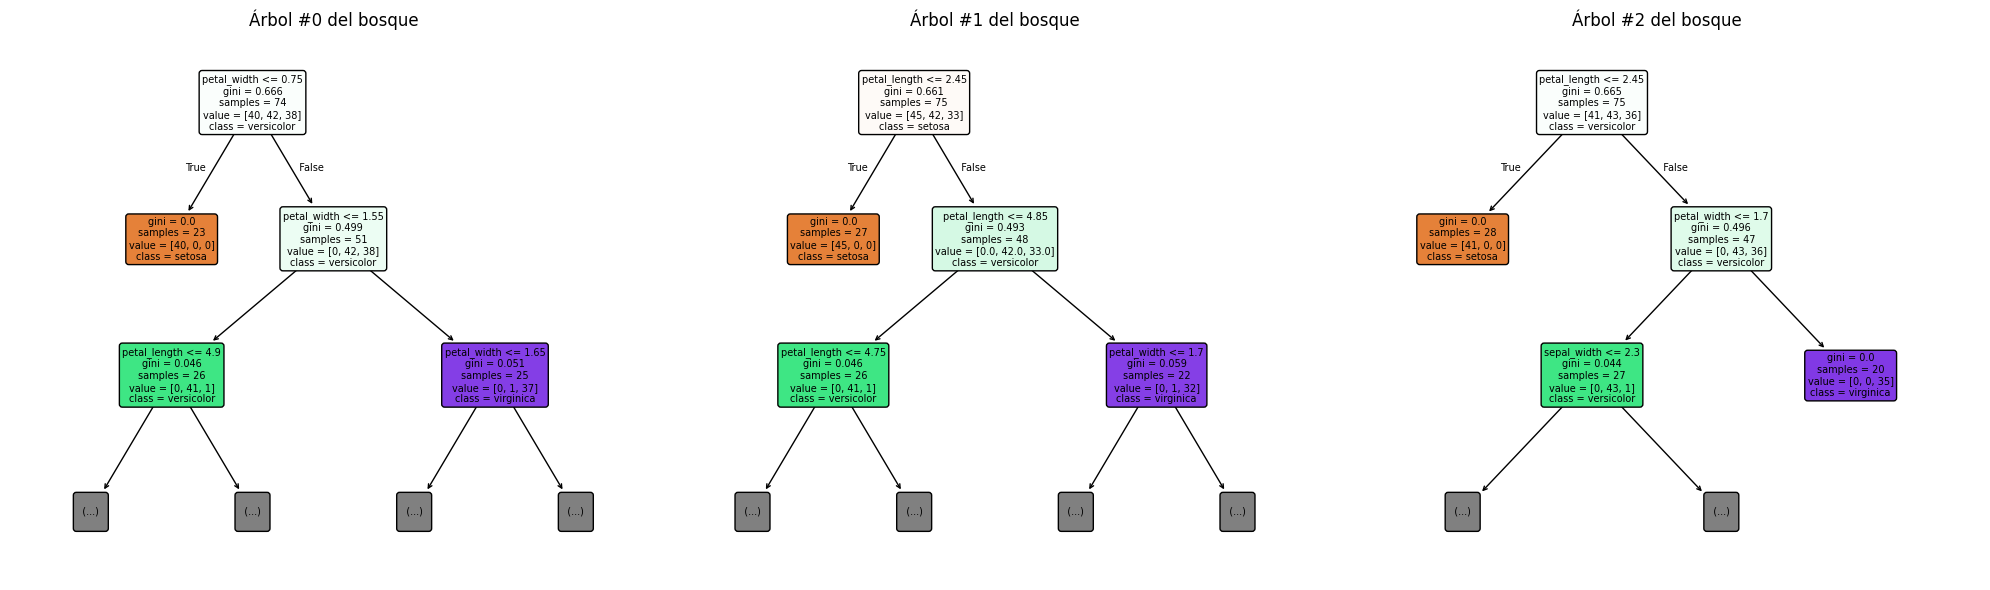

In [ ]:
clases=df.species.unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


for i, ax in enumerate(axes):
    plot_tree(bosque.estimators_[i],
              feature_names=X.columns.to_list(),
              class_names=clases,
              filled=True,
              rounded=True,
              fontsize=7,
              max_depth=2,
              ax=ax)
    ax.set_title(f"Árbol #{i} del bosque")

plt.tight_layout()
plt.show()

Fíjate que limitamos el dibujo a `max_depth=2`  solo para que la imagen sea legible; los árboles reales siguen creciendo más allá de ese nivel. Aun con esa limitación, se nota que **cada árbol hace su primera pregunta distinta**, o divide con umbrales distintos: eso es la aleatoriedad del bootstrap y de `max_features` en acción. Cuando el bosque hace una predicción, en el fondo les pregunta a los 100 árboles y se queda con la **clase más votada**.

# Predicciones y métricas de evaluación

In [ ]:
y_pred = bosque.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"Accuracy del árbol único : {acc_arbol:.2f}")
print(f"Accuracy del bosque      : {score:.2f}")

Accuracy del árbol único : 0.93
Accuracy del bosque      : 0.90


En un dataset tan pequeño y tan bien separado como *iris*, es esperable que ambos modelos anden muy parecido (incluso empatados en 1.00), porque el árbol individual ya lo hace casi perfecto. La ventaja real de los bosques aparece con datasets más grandes, más ruidosos o con más variables irrelevantes: ahí un solo árbol suele sobreajustarse y perder precisión sobre datos nuevos, mientras que el bosque, al promediar entre muchos árboles distintos, mantiene un rendimiento mucho más **robusto y estable**.

# Matriz de Confusión

In [ ]:
print("Matriz de Confusión:")
matriz = confusion_matrix(y_test, y_pred)
print(matriz)

Matriz de Confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


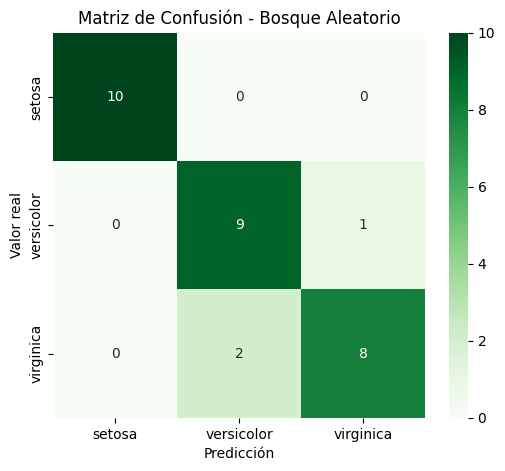

In [ ]:
etiquetas = ["setosa", "versicolor", "virginica"]

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Greens",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Bosque Aleatorio")
plt.show()

# Reporte de Clasificación

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=etiquetas))

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## Hiperparámetros: `n_estimators` y el puntaje Out-of-Bag (OOB)

Así como con los árboles vimos el efecto de `max_depth` sobre el sobreajuste, con los bosques el hiperparámetro más característico para explorar es **`n_estimators`** (la cantidad de árboles). En general, agregar más árboles **no** empeora el sobreajuste —a diferencia de aumentar `max_depth` en un árbol individual— sino que la mejora en accuracy tiende a **estabilizarse** (alcanzar una meseta) a partir de cierta cantidad, mientras que el tiempo de entrenamiento sigue creciendo.

Además, el Bagging nos regala una forma de validar el modelo *sin necesidad de un conjunto de prueba separado*: como cada árbol se entrena con una muestra bootstrap, en promedio **cerca de un tercio de las filas quedan afuera** de esa muestra para cada árbol (las filas *out-of-bag*, u OOB). Scikit-learn puede usar automáticamente esas filas "no vistas" por cada árbol para estimar el error del modelo, activando `oob_score=True`. Es, en cierto modo, una validación cruzada gratuita, incluida en el propio entrenamiento.

Vamos a entrenar bosques con distinta cantidad de árboles y comparar el *accuracy* de entrenamiento, de prueba, y el puntaje OOB.

In [ ]:
cantidades_arboles = [1, 3, 5, 10, 20, 50, 100, 200]
accuracy_entrena = []
accuracy_prueba = []
accuracy_oob = []

for n in cantidades_arboles:
    bosque_n = RandomForestClassifier(n_estimators=n,
                                       oob_score=True,
                                       bootstrap=True,
                                       random_state=42)
    bosque_n.fit(X_train, y_train)
    accuracy_entrena.append(accuracy_score(y_train, bosque_n.predict(X_train)))
    accuracy_prueba.append(accuracy_score(y_test, bosque_n.predict(X_test)))
    accuracy_oob.append(bosque_n.oob_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


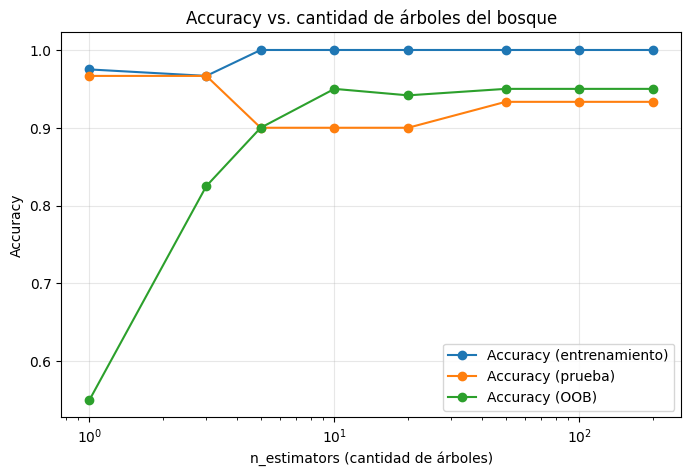

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(cantidades_arboles, accuracy_entrena, marker="o", label="Accuracy (entrenamiento)")
plt.plot(cantidades_arboles, accuracy_prueba, marker="o", label="Accuracy (prueba)")
plt.plot(cantidades_arboles, accuracy_oob, marker="o", label="Accuracy (OOB)")
plt.xlabel("n_estimators (cantidad de árboles)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. cantidad de árboles del bosque")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Como *iris* es un dataset chico y muy fácil de separar, es esperable que las tres curvas se acerquen a 1.00 rápidamente y con pocos árboles. Lo importante es la **forma general** de este gráfico, que sí se replica en datasets más difíciles: el *accuracy* mejora rápido al principio y después se **aplana**, así que agregar más y más árboles deja de aportar mejoras significativas (solo cuesta más tiempo de cómputo). También podés notar que la curva OOB se comporta de manera parecida a la de prueba, lo que confirma que es una buena estimación del error "real" del modelo, sin necesidad de haber reservado esos datos aparte.

## Importancia de las Variables (Feature Importances)

Al igual que con un árbol individual, un bosque también expone `feature_importances_`. La diferencia es que, al ser un **promedio calculado sobre los 100 árboles**, esta estimación es mucho más **estable y confiable** que la de un único árbol: un solo árbol puede haber elegido una variable "por casualidad" en su primera división, mientras que el promedio sobre muchos árboles entrenados con distintas muestras y distintos subconjuntos de variables tiende a reflejar mejor la importancia real de cada una.

In [ ]:
importancias_bosque = pd.Series(bosque.feature_importances_, index=X.columns).sort_values(ascending=False)
importancias_arbol = pd.Series(arbol.feature_importances_, index=X.columns)

comparacion = pd.DataFrame({
    "bosque": importancias_bosque,
    "arbol": importancias_arbol,
}).sort_values("bosque", ascending=False)

comparacion

,bosque,arbol
petal_width,0.432973,0.906015
petal_length,0.431579,0.058568
sepal_length,0.118396,0.006250
sepal_width,0.017052,0.029167


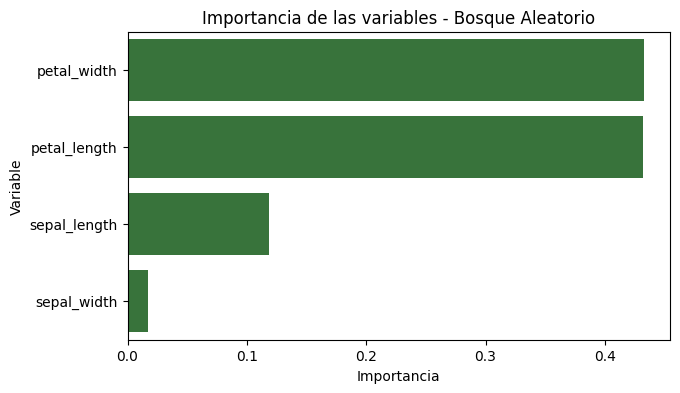

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(x=importancias_bosque.values, y=importancias_bosque.index, color="#2E7D32")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de las variables - Bosque Aleatorio")
plt.show()

Igual que en el árbol de la clase pasada, las variables del **pétalo** (`petal_length` y `petal_width`) siguen siendo, por lejos, las más importantes para distinguir entre especies, mientras que las del sépalo aportan mucho menos. Que ambos modelos coincidan en esto es una buena señal: nos da más confianza en que el patrón que encontraron es real, y no un artefacto de un único árbol en particular.

## Prediciendo una Flor Nueva

Repitamos el mismo ejemplo de la clase pasada: clasificar una flor que no está en el dataset, armando un `DataFrame` con las mismas columnas que usamos para entrenar.

In [ ]:
flor_nueva = pd.DataFrame([{
    "sepal_length": 5.8,
    "sepal_width": 2.7,
    "petal_length": 4.1,
    "petal_width": 1.0,
}])

prediccion_arbol = le.inverse_transform(arbol.predict(flor_nueva))
prediccion_bosque = le.inverse_transform(bosque.predict(flor_nueva))

print(f"Predicción del árbol : {prediccion_arbol[0]}")
print(f"Predicción del bosque: {prediccion_bosque[0]}")

ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


Algo que un árbol individual no puede ofrecernos de forma tan directa es una medida de **qué tan "convencido" está el modelo** de su predicción. Como el bosque en el fondo es una votación entre 100 árboles, podemos preguntarle qué proporción de árboles votó por cada clase, con `predict_proba`.

In [ ]:
probabilidades = bosque.predict_proba(flor_nueva)

pd.DataFrame(probabilidades, columns=le.classes_)

,setosa,versicolor,virginica
0,0.0,1.0,0.0


Cada columna representa la **fracción de los 100 árboles** del bosque que votó por esa especie para esta flor en particular. Si, por ejemplo, el resultado fuera algo como `setosa: 0.00`, `versicolor: 0.94`, `virginica: 0.06`, eso nos diría que la gran mayoría de los árboles coincidió en *versicolor*, pero que hubo algunos árboles (entrenados con una muestra o subconjunto de variables distinto) que "dudaron" y votaron *virginica*. Esta noción de confianza basada en el consenso entre árboles es una de las ventajas prácticas más usadas de los bosques aleatorios frente a un único árbol de decisión.

## Para Practicar

Antes de las conclusiones, te proponemos algunos ejercicios para reforzar lo aprendido. Podés agregar celdas nuevas debajo de esta para resolverlos:

1. **Cambiá `n_estimators`** al crear el `bosque` (por ejemplo `10`, `50`, `300`) y volvé a calcular el *accuracy* de prueba. ¿A partir de qué cantidad deja de notarse una mejora?
2. **Probá distintos valores de `max_features`** (por ejemplo `"sqrt"`, `"log2"`, `None` o un número fijo como `2`) y observá cómo cambian tanto el *accuracy* como la importancia relativa de las variables.
3. **Limitá la profundidad de los árboles individuales** del bosque con `max_depth` (por ejemplo `RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)`). ¿Cambia mucho el resultado, comparado con no limitarla? ¿Por qué creés que los bosques son menos sensibles a este parámetro que un árbol individual?
4. **Compará contra `ExtraTreesClassifier`** (de `sklearn.ensemble`), otro método de ensamble muy parecido al Bosque Aleatorio pero que además aleatoriza los umbrales de corte en cada división. ¿El *accuracy* cambia mucho respecto al `RandomForestClassifier`?
5. **Desafío:** repetí este mismo flujo de trabajo (entrenar árbol vs. bosque, comparar *accuracy*, ver importancia de variables) pero con un dataset más difícil, por ejemplo `sns.load_dataset("penguins")` (vas a necesitar `dropna()` antes de entrenar). ¿La diferencia entre el árbol y el bosque es más marcada que con *iris*?

## Conclusiones

En este cuaderno aprendimos a:

- Entender la idea central de los **Bosques Aleatorios**: combinar muchos árboles de decisión entrenados con **bootstrap** (bagging) y con una **selección aleatoria de variables** en cada división, para lograr predicciones más robustas que un único árbol.
- Entrenar un bosque con Scikit-learn (`RandomForestClassifier`) y comparar su *accuracy* contra un `DecisionTreeClassifier` entrenado con los mismos datos.
- **Visualizar** árboles individuales dentro del bosque (`bosque.estimators_`) y comprobar que cada uno es distinto.
- Usar el hiperparámetro **`n_estimators`** para controlar la cantidad de árboles, y entender por qué su efecto es distinto al de `max_depth` en un árbol individual (más árboles no aumenta el sobreajuste, solo el tiempo de cómputo).
- Aprovechar el **puntaje Out-of-Bag (`oob_score_`)** como una forma de validación "gratuita", incluida en el propio proceso de bagging.
- Leer la **importancia de las variables** promediada sobre todos los árboles del bosque, más estable que la de un árbol individual.
- Usar **`predict_proba`** para interpretar una predicción del bosque como una votación entre sus árboles, algo que un único árbol no ofrece de forma tan natural.

Los Bosques Aleatorios son uno de los algoritmos de *ensamble* más usados en la práctica, junto con otra familia de métodos que combina árboles de una manera distinta —entrenándolos uno tras otro, cada uno corrigiendo los errores del anterior— conocida como ***Boosting*** (por ejemplo, Gradient Boosting o XGBoost), que podría ser un buen tema para una próxima clase.